In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
warnings.filterwarnings('ignore')

In [16]:
tested = pd.read_csv('tested.csv')
tested.shape
# (891, 12)

(418, 12)

In [4]:
tested.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


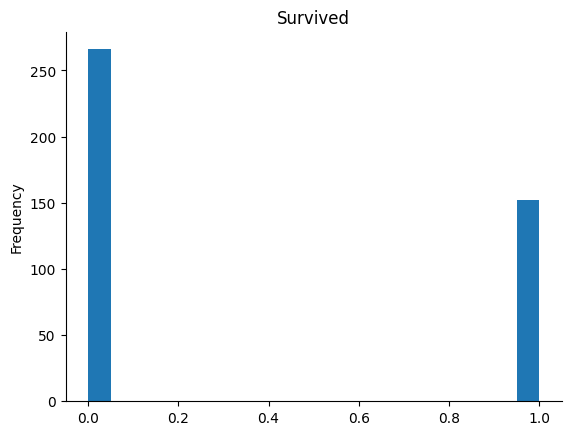

In [6]:
from matplotlib import pyplot as plt
tested['Survived'].plot(kind='hist', bins=20, title='Survived')
plt.gca().spines[['top', 'right',]].set_visible(False)

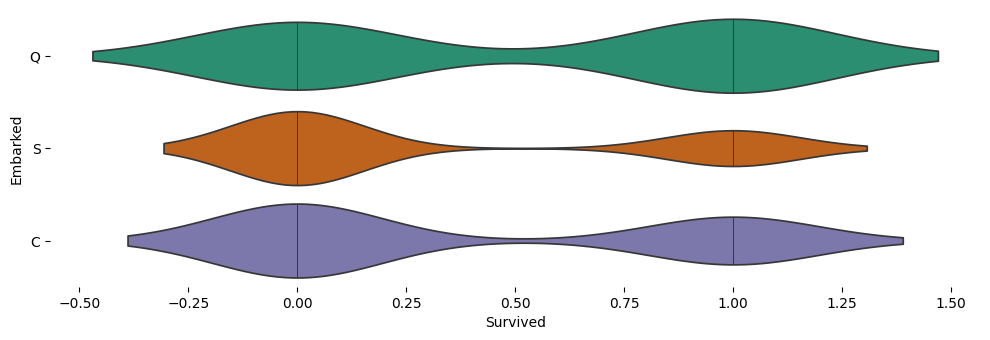

In [5]:
from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(tested['Embarked'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(tested, x='Survived', y='Embarked', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [18]:


# Drop unnecessary columns
tested = tested.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Fill missing age values with the median age
tested['Age'].fillna(tested['Age'].median(), inplace=True)

# Fill missing embarked values with the most frequent value
tested['Embarked'].fillna(tested['Embarked'].mode()[0], inplace=True)

# Convert categorical features to numerical using one-hot encoding
tested = pd.get_dummies(tested, columns=['Sex', 'Embarked'])

# Define features (X) and target (y)
X = tested.drop('Survived', axis=1)
y = tested['Survived']

# Impute missing values in all columns of X using the median
# This addresses potential NaNs in other columns besides 'Age' and 'Embarked'
for col in X.columns:
    X[col].fillna(X[col].median(), inplace=True) # or use X[col].fillna(X[col].mode()[0], inplace=True) for categorical features


# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 1.0


In [19]:
# Examine features and target
print("Features (X):\n", X.head())  # Print first few rows of features
print("\nTarget (y):\n", y.head())  # Print first few rows of target


Features (X):
    Pclass   Age  SibSp  Parch     Fare  Sex_female  Sex_male  Embarked_C  \
0       3  34.5      0      0   7.8292       False      True       False   
1       3  47.0      1      0   7.0000        True     False       False   
2       2  62.0      0      0   9.6875       False      True       False   
3       3  27.0      0      0   8.6625       False      True       False   
4       3  22.0      1      1  12.2875        True     False       False   

   Embarked_Q  Embarked_S  
0        True       False  
1       False        True  
2        True       False  
3       False        True  
4       False        True  

Target (y):
 0    0
1    1
2    0
3    0
4    1
Name: Survived, dtype: int64


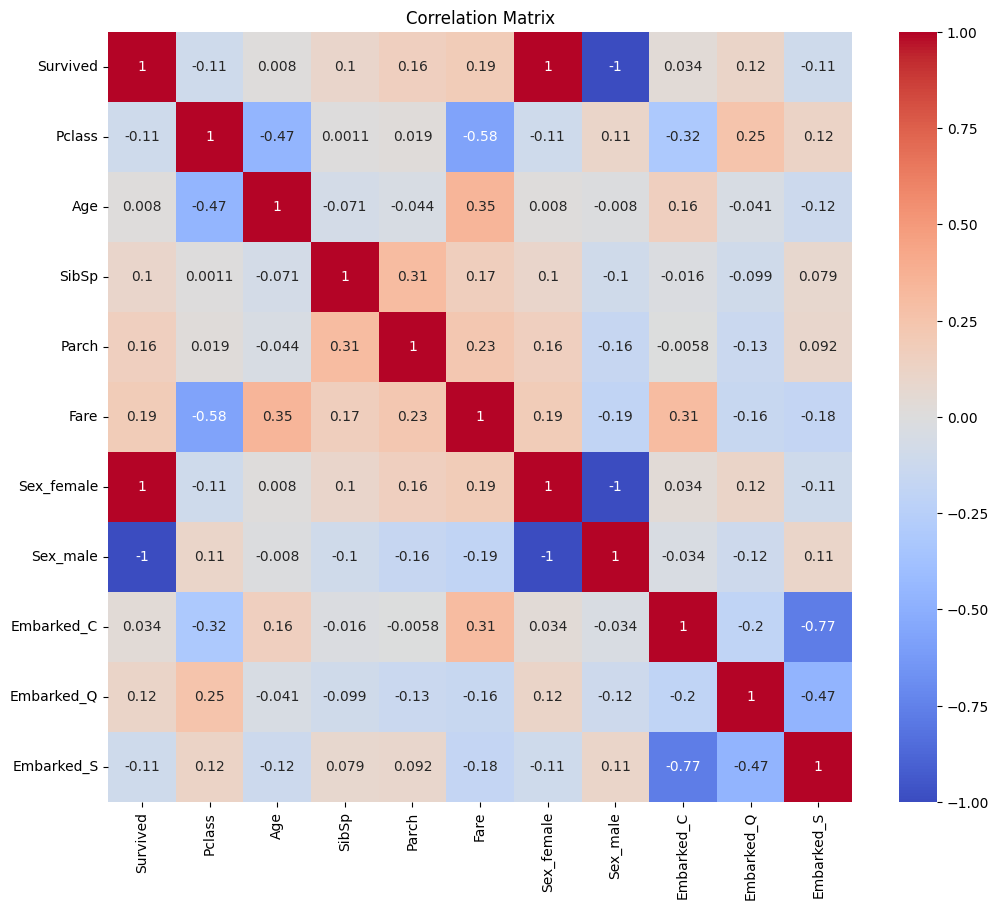

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'tested' is your DataFrame after one-hot encoding
correlation_matrix = tested.corr()

plt.figure(figsize=(12, 10))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [21]:
tested = pd.read_csv('tested.csv')
# Drop unnecessary columns
tested = tested.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Fill missing age values with the median age
tested['Age'].fillna(tested['Age'].median(), inplace=True)

# Fill missing embarked values with the most frequent value
tested['Embarked'].fillna(tested['Embarked'].mode()[0], inplace=True)

# Convert categorical features to numerical using one-hot encoding
tested = pd.get_dummies(tested, columns=['Sex', 'Embarked'])

# Define features (X) and target (y)
X = tested.drop('Survived', axis=1)
y = tested['Survived']

# Calculate correlation
correlations = tested.corr()['Survived'].sort_values(ascending=False)
print(correlations)


Survived      1.000000
Sex_female    1.000000
Fare          0.191514
Parch         0.159120
Embarked_Q    0.115574
SibSp         0.099943
Embarked_C    0.033684
Age           0.008035
Embarked_S   -0.105883
Pclass       -0.108615
Sex_male     -1.000000
Name: Survived, dtype: float64
